# FINAL PROJECT

## Modeling IL2RA Gene Regulation and Lupus Risk through Transformer-Based Analysis

Lupus is a disease involving a loss of tolerance. The body stops recognizing what is its own and attacks itself. IL2RA is the name of the gene (located on chromosome 10). Its function is to manufacture a protein (the CD25 receptor) that helps T lymphocytes stay under control. The IL2RA (CD25) gene encodes a part of the Interleukin-2 (IL-2) receptor. IL-2 is like the "fuel" for lymphocytes. Regulatory T Lymphocytes (Tregs) are the "police" of the immune system. Their job is to turn off inflammation. Tregs depend entirely on a high expression of IL2RA to function. The failure in Lupus (Farh et al) shows that genetic variants often "close" the DNA near IL2RA in T lymphocytes. If the DNA closes (low accessibility), the T lymphocyte cannot express enough IL2RA, the "police" (Tregs) weaken, and the immune system enters a state of perpetual attack. The problem is a prediction problem of whether the DNA is CLOSED (Low accessibility).

## Task 3.

Methodology:

1. Training Phase: DNABERT is employed to predict BED/BigWig values directly from DNA sequences through supervised learning. The model learns the functional relationship between DNA primary sequence and ATAC-seq signal intensity.

Input (X): 512bp DNA sequences. Output/Target (Y): ATAC-seq signal intensity (CD4+ T cells / T lymphocytes) for those specific sequences (Source: ENCODE). A dataset is constructed by defining an analysis window based on the coordinates of the IL2RA enhancer (UCSC Genome Browser) using the hg38 reference genome.

2. Validation: Prediction of IL2RA chromatin accessibility compared against the ground-truth BED/BigWig data. Performance is validated using Pearson and Spearman correlation coefficients.

3. In Silico Genomics: Introduction of Lupus-specific pathogenic variants into the enhancer sequence to quantify risk by predicting changes in chromatin accessibility.

Data Sources: Enhancer definitions are based on the study by Andersson, R., et al. (2014). An atlas of active enhancers across human cell types and tissues. Nature. The specific pathogenic variant is rs10795763 (sourced from the GWAS Catalog).

SNP Mechanism ("Letter Change"): Substitution of A (Adenine) for G (Guanine). Healthy Allele (A): Maintains an "unrolled" (open) DNA state, allowing transcription factors to bind. Risk Allele (G): Acts as a "blockade." Studies indicate this variant significantly reduces chromatin accessibility.

Motif Analysis and Risk Quantification: Mapping and sequence analysis are used to determine if the nucleotide substitution occurs precisely within the coordinates of the STAT5 protein recognition motif. If the variant disrupts the STAT5 motif, it can be concluded that the signal peak dropped because the variant destroyed the STAT5 binding site. The biological impact is quantified by comparing the two results (Healthy vs. Mutated) to measure the magnitude of the difference.  

In [15]:
# Erasing
!rm -f *.fa *.fa.gz *.fai

# Erasing
!rm -f *.bed.gz *.txt.gz

In [16]:
# Download chormosome training
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr2.fa.gz
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr8.fa.gz

# Download chr10 (IL2RA and rs10795763)
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz


# Download Chromosome for Validation
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr19.fa.gz

# Gene Table for Precisely Locating IL2RA
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/ncbiRefSeq.txt.gz


# Download the BED file (Target Y) - Selected from ENCODE
# This file contains the open chromatin peak coordinates for CD4+ T cells
!wget https://www.encodeproject.org/files/ENCFF246KRE/@@download/ENCFF246KRE.bed.gz

# Install necessary libraries. pyfaidx is an "efficient reader" for large DNA sequence files (FASTA)
!pip install pyfaidx pandas biopython

--2026-05-03 22:51:05--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74778116 (71M) [application/x-gzip]
Saving to: ‘chr1.fa.gz’

chr1.fa.gz          100%[===================>]  71.31M  94.7MB/s    in 0.8s    

2026-05-03 22:51:05 (94.7 MB/s) - ‘chr1.fa.gz’ saved [74778116/74778116]

--2026-05-03 22:51:06--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr2.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78561132 (75M) [application/x-gzip]
Saving to: ‘chr2.fa.gz’

chr2.fa.gz          100%[===================>]  74.92M   161MB/s 

In [17]:
!gunzip -f chr1.fa.gz chr2.fa.gz chr8.fa.gz chr10.fa.gz chr19.fa.gz ENCFF246KRE.bed.gz ncbiRefSeq.txt.gz
!ls -lh *.fa *.bed *.txt

### Building the Dataset

#### Target Data (Y): Chromatin Accessibility Peaks

Source: ENCODE Project Portal.

Experiment ID: ENCSR841LHT

Biosample: Human CD4-positive, alpha-beta T cells (Primary cells from a 20-year-old male adult).

Assay Type: ATAC-seq (Assay for Transposase-Accessible Chromatin using sequencing).

Genome Assembly: GRCh38 (hg38).

File Accession: ENCFF246KRE

File Format: BED narrowPeak (Gzipped).

Data Processing: Pseudoreplicated peaks (Integrative analysis of biological replicates to ensure high-confidence open chromatin regions).

Download link (directly): https://www.encodeproject.org/files/ENCFF246KRE/

#### X features

Download link (directly): https://hgdownload-test.gi.ucsc.edu/goldenPath/hg38/chromosomes/

In [19]:
from pyfaidx import Fasta

chromosomes = ['chr1', 'chr2', 'chr8', 'chr10', 'chr19']
genome = {}

for chrom in chromosomes:
    fasta_file = f'{chrom}.fa'
    # Index each file for fast random access
    genome[chrom] = Fasta(fasta_file)[chrom]

print("✅ Genome loaded: ", genome.keys())

✅ Genome loaded:  dict_keys(['chr1', 'chr2', 'chr8', 'chr10', 'chr19'])


## Creating Dataset XY

Taking each row in the BED file (ATAC-seq), extract the start and end positions, and cut the corresponding sequence from the FASTA file (genome).

In [55]:
# Load file BED
df_bed = pd.read_csv('ENCFF246KRE.bed', sep='\t', header=None,
                     names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signal', 'p', 'q', 'peak'])

train_chroms = ['chr8']
val_chroms = ['chr19']
test_region = ['chr10']


# Training: chr8
df_train = df_bed[df_bed['chrom'].isin(train_chroms)].drop_duplicates(subset=['start', 'end'])

# Validation: chr19
df_val = df_bed[df_bed['chrom'].isin(val_chroms)].drop_duplicates(subset=['start', 'end'])

# Testing: chr10 (intereting area)
df_test = df_bed[df_bed['chrom'].isin(test_region)].drop_duplicates(subset=['start', 'end'])

# Generation of sequences (X) and labels (Y)

# Traing Set
X_train, Y_train = prepare_genomic_data(df_train, genome, window_size=128)

# Validation Set
X_val, Y_val = prepare_genomic_data(df_val, genome, window_size=128)

# Testing Set de Testing (Cromosoma 10)
# 'Y_test_real' these will be the actual ENCODE labels used for comparison in the graph.
X_test, Y_test_real = prepare_genomic_data(df_test, genome, window_size=128)


print(f"✅ Procesamiento completado:")
print(f"- Training (Chr8):   {len(X_train)} secuencias | {len(Y_train)} labels")
print(f"- Validation (Chr19): {len(X_val)} secuencias | {len(Y_val)} labels")
print(f"- Testing (Chr10):    {len(X_test)} secuencias | {len(Y_test_real)} labels")


✅ Procesamiento completado:
- Training (Chr8):   2396 secuencias | 2396 labels
- Validation (Chr19): 3102 secuencias | 3102 labels
- Testing (Chr10):    2875 secuencias | 2875 labels


# Chromatin Signal

In [57]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

df_chr10 = df_bed[df_bed['chrom'] == 'chr10']

def plot_interactive_genomics(start_pos):
    # Define a fixed window (e.g. 50kb)
    window_size = 50000
    end_pos = start_pos + window_size

    # Filter peaks within the selected window
    plot_data = df_chr10[(df_chr10['start'] >= start_pos) & (df_chr10['end'] <= end_pos)]

    plt.figure(figsize=(15, 6))

    if not plot_data.empty:
        plt.stem(plot_data['start'], plot_data['signal'],
                 linefmt='b-', markerfmt='bo', basefmt='r-',
                 label='ATAC-seq Peaks (CD4+ T-Cells)')

    # Coordinates of interest
    enhancer_start, enhancer_end = 6062260, 6062609
    il2ra_body_start, il2ra_body_end = 6010687, 6062335

    # Draw reference areas if they are within the visual range
    plt.axvspan(il2ra_body_start, il2ra_body_end, color='green', alpha=0.1, label='IL2RA Gene Body')
    plt.axvspan(enhancer_start, enhancer_end, color='orange', alpha=0.5, label='Enhancer (SNP rs10795763)')

    plt.title(f'Genome Explorer: Region chr10:{start_pos}-{end_pos}', fontsize=15)
    plt.xlabel('Genomic Position on Chr10 (bp)', fontsize=12)
    plt.ylabel('Signal Intensity (Accessibility)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.ylim(0, df_chr10['signal'].max() + 5) # Keep Y-axis scale constant
    plt.legend(loc='upper right')

    plt.show()

# interactive Widget
interact(plot_interactive_genomics,
         start_pos=widgets.IntSlider(
             value=6010000,
             min=5950000,
             max=6100000,
             step=5000,
             description='Position:',
             layout={'width': '90%'},
             continuous_update=False # Prevents flickering when moving the slider quickly
         ))

interactive(children=(IntSlider(value=6010000, continuous_update=False, description='Position:', layout=Layout…

<function __main__.plot_interactive_genomics(start_pos)>

In [58]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np

# Ensure Chromosome 10 data is filtered and sorted by starting position
df_chr10 = df_bed[df_bed['chrom'] == 'chr10'].sort_values('start')

def plot_continuous_chromatin(start_pos):
    # Define window width (50kb to provide genomic context)
    window_size = 50000
    end_pos = start_pos + window_size

    # Filter peaks within the selected range
    mask = (df_chr10['start'] >= start_pos) & (df_chr10['end'] <= end_pos)
    plot_data = df_chr10[mask]

    plt.figure(figsize=(15, 5))

    if not plot_data.empty:
        # creates a "mountain" profile
        plt.fill_between(plot_data['start'], plot_data['signal'], color='royalblue', alpha=0.7, label='ATAC-seq Signal')
        plt.plot(plot_data['start'], plot_data['signal'], color='blue', lw=0.5, alpha=0.8)

    # Highlight the Enhancer and the IL2RA Gene
    # Enhancer containing SNP rs10795763 (associated with Lupus)
    plt.axvspan(6062260, 6062609, color='orange', alpha=0.4, label='Enhancer (Target Region)')
    # IL2RA gene body coordinates
    plt.axvspan(6010687, 6062335, color='green', alpha=0.1, label='IL2RA Gene Body')


    plt.title(f'Continuous Chromatin Accessibility - Chr10: {start_pos:,} to {end_pos:,} bp', fontsize=14)
    plt.xlabel('Genomic Position (hg38)', fontsize=12)
    plt.ylabel('Intensity (Signal Value)', fontsize=12)
    plt.xlim(start_pos, end_pos)
    plt.ylim(0, df_chr10['signal'].max() * 1.1)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Launch the Interactive Widget
interact(plot_continuous_chromatin,
         start_pos=widgets.IntSlider(
             value=6010000,
             min=5950000,
             max=6150000,
             step=2000,
             description='Navigate:',
             layout={'width': '95%'},
             continuous_update=False # Prevents lagging during rapid slider movement
         ))

interactive(children=(IntSlider(value=6010000, continuous_update=False, description='Navigate:', layout=Layout…

<function __main__.plot_continuous_chromatin(start_pos)>

In [26]:
#Y_train = np.log1p(Y_train) # log(1 + x)
#Y_val = np.log1p(Y_val)

# Chromatin Raw

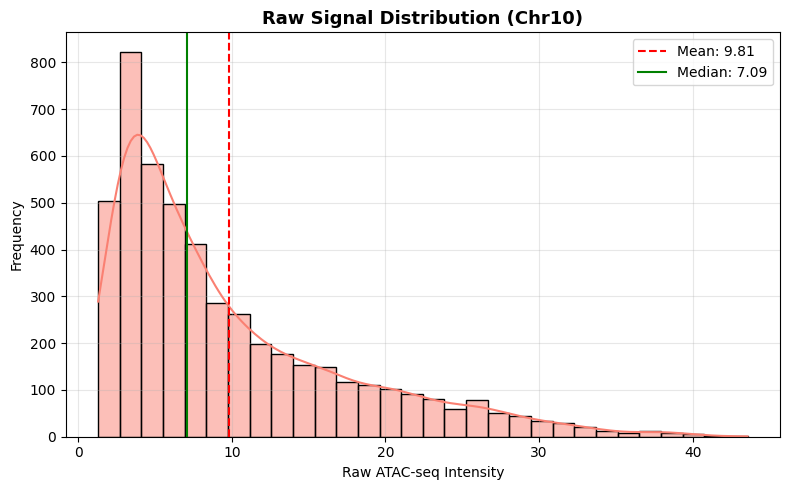

📊 SKEWNESS ANALYSIS - CHROMOSOME 10
Raw Data Skewness: 1.3405
Note: High skewness suggests that most peaks have low intensity,
while a few 'super-peaks' hold disproportionately high values.


In [59]:
import seaborn as sns
from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt

# Prepare Chromosome
y_chr10_raw = df_chr10['signal'].values

# Configure Visualization
plt.figure(figsize=(8, 5))

# Histogram: Raw Signal Distribution
sns.histplot(y_chr10_raw, kde=True, color='salmon', bins=30)

# Add Mean and Median lines for reference
plt.axvline(np.mean(y_chr10_raw), color='red', linestyle='--',
            label=f'Mean: {np.mean(y_chr10_raw):.2f}')
plt.axvline(np.median(y_chr10_raw), color='green', linestyle='-',
            label=f'Median: {np.median(y_chr10_raw):.2f}')

plt.title('Raw Signal Distribution (Chr10)', fontsize=13, fontweight='bold')
plt.xlabel('Raw ATAC-seq Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness Analysis
raw_skew = skew(y_chr10_raw)

print(f"{'='*50}")
print(f"📊 SKEWNESS ANALYSIS - CHROMOSOME 10")
print(f"{'='*50}")
print(f"Raw Data Skewness: {raw_skew:.4f}")
print(f"{'='*50}")
print("Note: High skewness suggests that most peaks have low intensity,")
print("while a few 'super-peaks' hold disproportionately high values.")

# Genomic Dataset and Tokenization

In [28]:
from torch.utils.data import Dataset, DataLoader
import torch

class GenomicDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_length=128):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):

        # Tokenization ADN sequence
        inputs = self.tokenizer(
            self.sequences[idx],
            return_tensors='pt',
            max_length=self.max_length,
            padding='max_length',
            truncation=True
        )

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [60]:
# Check if the initial filtering worked
print(f"Rows in df_train: {len(df_train)}")

# Check the result of prepare_genomic_data
print(f"Sequences in X_train: {len(X_train)}")

# If X_train is 0, check your dictionary keys
print(f"Genome dictionary keys: {list(genome.keys())}")
print(f"Unique chromosomes in df_train: {df_train['chrom'].unique()}")

Rows in df_train: 2396
Sequences in X_train: 2396
Genome dictionary keys: ['chr1', 'chr2', 'chr8', 'chr10', 'chr19']
Unique chromosomes in df_train: ['chr8']


# Genomic Dataset (k-mers) and Tokenization

In [62]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

# Function to convert sequences to 6-mers
def seq_to_kmers(seq, k=6):
    return " ".join([seq[i:i+k] for i in range(len(seq) - k + 1)])

# converting your raw data.
X_train_kmers = [seq_to_kmers(s) for s in X_train]
X_val_kmers = [seq_to_kmers(s) for s in X_val]

# PyTorch Dataset Definition
class GenomicDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_length=128):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Tokenización
        encoding = self.tokenizer(
            self.sequences[idx],
            return_tensors='pt',
            max_length=self.max_length,
            padding='max_length',
            truncation=True
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

# Loading Tokenizer and creating DataLoaders
tokenizer = BertTokenizer.from_pretrained("zhihan1996/DNA_bert_6")

train_dataset = GenomicDataset(X_train_kmers, Y_train, tokenizer)
val_dataset = GenomicDataset(X_val_kmers, Y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Defining the Regression Head for DNABERT-2 for predicting Chromatin opening

# Regressor Loss 2 layer

In [101]:
class DNABertRegressor(nn.Module):
    def __init__(self, model_name="zhihan1996/DNA_bert_6"):
        super(DNABertRegressor, self).__init__()
        self.dnabert = BertModel.from_pretrained(model_name)

        # Improved Head: Added an extra linear layer and GELU activation
        # to help model overdispersion before the final output
        self.regressor = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.dnabert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        return self.regressor(pooled_output)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final = DNABertRegressor().to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Regressor Loss 1 layer

In [95]:
import torch
import torch.nn as nn
from transformers import BertModel

class DNABertRegressor(nn.Module):
    def __init__(self, model_name="zhihan1996/DNA_bert_6"):
        super(DNABertRegressor, self).__init__()
        # Load the pre-trained base model
        self.dnabert = BertModel.from_pretrained(model_name)

        # Regression head with Dropout to prevent overfitting
        self.regressor = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(768, 1) # DNABERT-base has a hidden dimension of 768
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.dnabert(input_ids=input_ids, attention_mask=attention_mask)

        # using the pooler_output (representation of the [CLS] token)
        # It passed through a Linear + Tanh layer
        pooled_output = outputs.pooler_output

        # Return the regression value (ATAC-seq signal prediction)
        return self.regressor(pooled_output)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🖥️ Training will run on: {device}")

# Initialize the model
model_final = DNABertRegressor().to(device)

🖥️ Training will run on: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Native Binomial Loss in the Forward

In [98]:
class NegativeBinomialLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super(NegativeBinomialLoss, self).__init__()
        self.eps = eps

    def forward(self, log_pred, target):

        log_pred = log_pred.view(-1)
        target = target.view(-1)

        pred = torch.exp(log_pred)
        alpha = 1.0

        alpha_t = torch.as_tensor(alpha, dtype=pred.dtype, device=pred.device)

        term1 = torch.lgamma(target + alpha_t) - torch.lgamma(target + 1) - torch.lgamma(alpha_t)
        term2 = alpha_t * torch.log(alpha_t / (alpha_t + pred + self.eps))
        term3 = target * torch.log(pred / (alpha_t + pred + self.eps))

        return -torch.mean(term1 + term2 + term3)

nb_criterion = NegativeBinomialLoss()

# Training

In [102]:
import torch.optim as optim
import torch.nn as nn
from scipy.stats import pearsonr

# loss function
# log_input=True interprets the model output as log(y)
poisson_criterion = nn.PoissonNLLLoss(log_input=True, full=True)


# Optimizer with learning rates for stability
# Lower LR for the pre-trained DNABERT, higher for the new regressor head
optimizer = optim.AdamW([
    {'params': model_final.dnabert.parameters(), 'lr': 1e-5},
    {'params': model_final.regressor.parameters(), 'lr': 1e-4}
], weight_decay=0.01)

print("🚀 Starting optimized training using Poisson Loss function")

for epoch in range(10):
    # Training
    model_final.train()
    total_train_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        # Raw signal
        labels = batch['labels'].to(device).flatten()

        optimizer.zero_grad()

        preds = model_final(input_ids, attention_mask).flatten()

        total_loss = poisson_criterion(preds, labels)
        #total_loss = nb_criterion(log_preds, labels)

        total_loss.backward()
        optimizer.step()

        total_train_loss += total_loss.item()

    # Validation(Chr19)
    model_final.eval()
    val_preds_real, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).flatten()

            # Model raw output
            log_preds = model_final(input_ids, attention_mask).flatten()

            # to converts log-space back to the original ATAC-seq intensity scale
            preds_real = torch.exp(log_preds)

            val_preds_real.extend(preds_real.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # Calculate final Validation Pearson correlation on the real scale
    corr, _ = pearsonr(val_preds_real, val_labels)

    print(f"Epoch {epoch+1} | Loss: {total_train_loss/len(train_loader):.4f} | Val Pearson: {corr:.4f}")

🚀 Starting optimized training using Poisson Loss function
Epoch 1 | Loss: 8.4193 | Val Pearson: 0.0879
Epoch 2 | Loss: 4.9610 | Val Pearson: 0.1045
Epoch 3 | Loss: 4.8567 | Val Pearson: 0.1082
Epoch 4 | Loss: 4.8200 | Val Pearson: 0.1267
Epoch 5 | Loss: 4.7903 | Val Pearson: 0.1250
Epoch 6 | Loss: 4.7379 | Val Pearson: 0.1315
Epoch 7 | Loss: 4.6991 | Val Pearson: 0.1366
Epoch 8 | Loss: 4.6765 | Val Pearson: 0.1300
Epoch 9 | Loss: 4.6620 | Val Pearson: 0.1226
Epoch 10 | Loss: 4.6501 | Val Pearson: 0.1204


# Validation

In [103]:
import torch
from scipy.stats import pearsonr
import numpy as np

# Validation Configuration
model_final.eval()
val_preds_real, val_labels = [], []

print(f"🔬 Validation {val_chroms} (real scale) ...")

with torch.no_grad():
    for batch in val_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).flatten()

        # Inference: The model returns predictions on a logarithmic scale (log_preds)
        log_preds = model_final(input_ids, attention_mask).flatten()

        # Changing the scale (reverting the logarithm to the original scale)
        real_predictions = torch.exp(log_preds)

        # saving
        val_preds_real.extend(real_predictions.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

# Metrics
y_val_preds = np.array(val_preds_real)
Y_val = np.array(val_labels)

# Calculate Pearson correlation on the original scale
correlation, _ = pearsonr(Y_val, y_val_preds)

print(f"{'='*40}")
print(f"✅ Validation completed")
print(f"📊 Pearson Correlation (Real Scale): {correlation:.4f}")
print(f"📉 Validated samples: {len(Y_val)}")
print(f"{'='*40}")

🔬 Validation ['chr19'] (real scale) ...
✅ Validation completed
📊 Pearson Correlation (Real Scale): 0.1204
📉 Validated samples: 3102


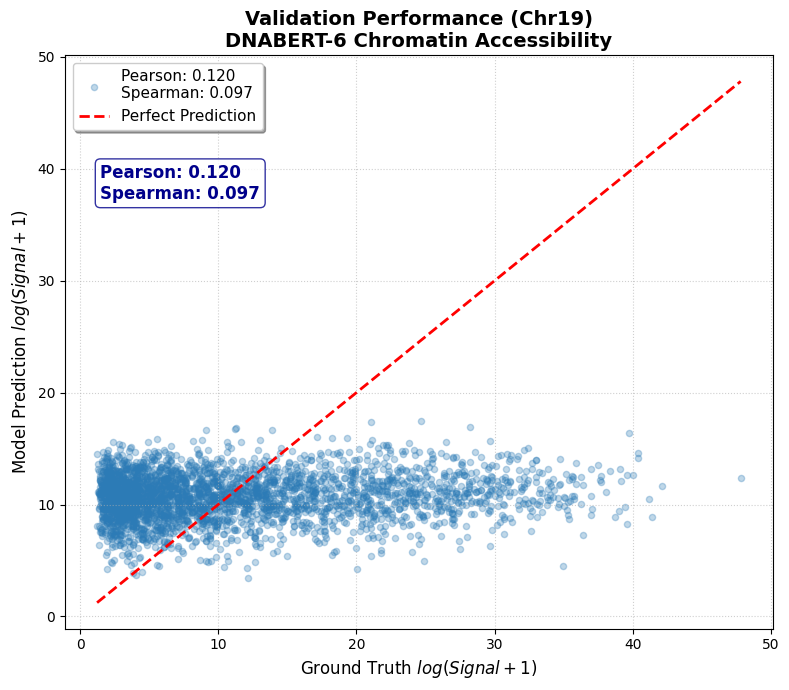

In [104]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# preparing data
y_p = np.array(y_val_preds).flatten()
y_v = np.array(Y_val).flatten()

# Metrics
# Pearson: lineal
# Spearman: rank
pearson_val, _ = pearsonr(y_v, y_p)
spearman_val, _ = spearmanr(y_v, y_p)


plt.figure(figsize=(8, 7))
plt.scatter(y_v, y_p, alpha=0.3, color='#2c7bb6', s=20,
            label=f'Pearson: {pearson_val:.3f}\nSpearman: {spearman_val:.3f}')

# identity line
lims = [np.min([y_v.min(), y_p.min()]), np.max([y_v.max(), y_p.max()])]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')


plt.title('Validation Performance (Chr19)\nDNABERT-6 Chromatin Accessibility', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth $log(Signal + 1)$', fontsize=12)
plt.ylabel('Model Prediction $log(Signal + 1)$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, fontsize=11, shadow=True)

# Text
plt.annotate(f'Pearson: {pearson_val:.3f}\nSpearman: {spearman_val:.3f}',
             xy=(0.05, 0.75), xycoords='axes fraction',
             fontsize=12, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkblue", alpha=0.8))

plt.tight_layout()
plt.show()

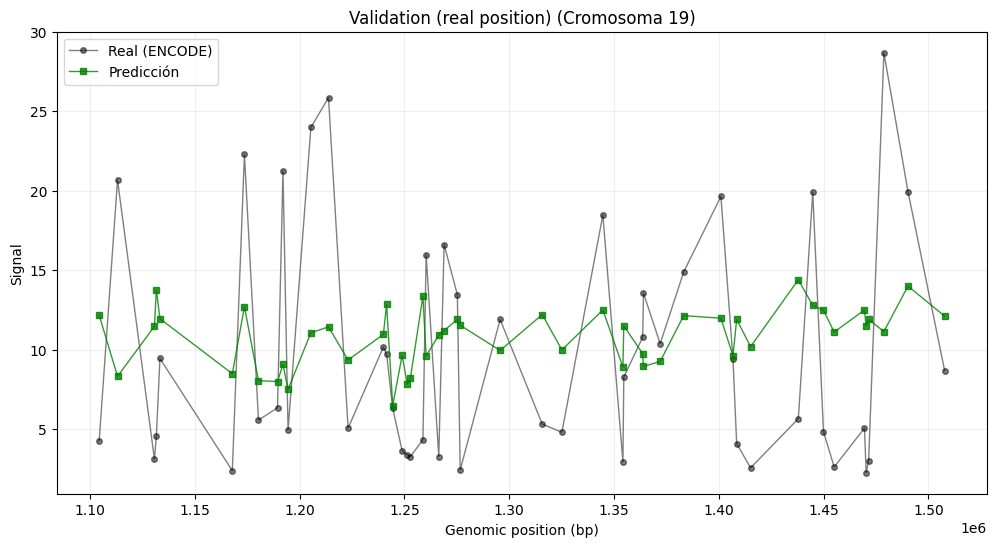

In [106]:
# Define the IL2RA gene region in hg38 (Chromosome 10)
# These coordinates cover the main body of the gene
# Analysis Windows based on UCSC Genome Browser on Human (GRCh38/hg38)
# Datos:
# hg38 Human: ENCODE4 Registry of candidate Cis-Regulatory Elements (cCREs) (EH38E2883624)
# Position: chr10:6062260-6062609

#gen_start = 6010000
#gen_end = 6065000
# crom 19 y 8
df_val_plot = df_val.copy()
df_val_plot['prediction'] = val_preds_real
df_val_plot['signal_real'] = val_labels

# Sort by genomic position
df_val_plot = df_val_plot.sort_values('start')

# Plot a small segment.
df_segmento = df_val_plot.iloc[100:150]

plt.figure(figsize=(12, 6))

plt.plot(df_segmento['start'], df_segmento['signal_real'],
         'k-o', label='Real (ENCODE)', markersize=4, alpha=0.5, linewidth=1)
plt.plot(df_segmento['start'], df_segmento['prediction'],
         'g-s', label='Predicción', markersize=4, alpha=0.8, linewidth=1)

plt.title('Validation (real position) (Cromosoma 19)')
plt.xlabel('Genomic position (bp)')
plt.ylabel('Signal')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Analizing Chromatic accessibility (ATAC-seq) in healthy patient

## Checking chromatin near the risk variant (SNP rs10795763)

[Enhancer positions (See)](https://imgur.com/xvEyOV2.png)

In [ ]:
# Using (GWAS catalog --> systemic lupus erythematosus in IL2RA --> rs10795763)


Regression task where the model learns to map a specific DNA sequence to a continuous numerical value representing chromatin openness